# 05 - Driver Behavior Modeling (Research Grade)

Objective:
- Build a fully data-driven, non-rule-based temporal behavior modeling pipeline using NB4 outputs.
- Learn sequence-level driver representations and risk dynamics from context trajectories and engineered features.

Core properties:
- Strict reproducibility.
- Trip-wise temporal integrity.
- Sequence modeling + representation learning.
- No hardcoded behavior definitions.

In [1]:
# Cell 2: Imports, deterministic setup, and global configuration

from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import gaussian_kde
import hashlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

try:
    import umap
except Exception as exc:
    raise ImportError("Please install umap-learn in your environment.") from exc

# --------------------------
# Deterministic configuration
# --------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
try:
    mixed_precision.set_global_policy("mixed_float16")
except Exception:
    pass

# --------------------------
# Paths and directories
# --------------------------
PROJECT_ROOT = Path("..")
INPUT_CSV = PROJECT_ROOT / "data" / "features" / "final_features_with_context.csv"
OUTPUT_CSV = PROJECT_ROOT / "data" / "features" / "final_driver_behavior.csv"
DRIVER_PROFILE_CSV = PROJECT_ROOT / "data" / "features" / "driver_profile.csv"
EMBEDDING_METRICS_CSV = PROJECT_ROOT / "data" / "features" / "embedding_metrics.csv"
FEATURE_IMPORTANCE_CSV = PROJECT_ROOT / "data" / "features" / "feature_importance.csv"

MODEL_DIR = PROJECT_ROOT / "models" / "driver_behavior_v4"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------
# Notebook-wide parameters
# --------------------------
SEQUENCE_LENGTH = 20
BATCH_SIZE = 256
EPOCHS = 12
MC_DROPOUT_PASSES = 12
MAX_CLUSTER_SAMPLE = 20000
TARGET_WINDOWS = 80000
PRIMARY_ARCHITECTURE = "bilstm_attn"
OPTIONAL_ARCHITECTURES = ["transformer"]
FIXED_CONTRASTIVE_TEMPERATURE = 0.1

REQUIRED_COLUMNS = [
    "trip_id",
    "window_id",
    "cluster_label",
    "cluster_label_smoothed",
    "context_confidence_score",
    "reconstruction_error",
    "is_anomaly",
]

start_time = time.time()
stage_start_times: Dict[str, float] = {"initialization": start_time}
stage_end_times: Dict[str, float] = {}
print(f"Input file: {INPUT_CSV.resolve()}")
print(f"Model directory: {MODEL_DIR.resolve()}")
print("Deterministic seed set to", RANDOM_STATE)
print("Primary architecture:", PRIMARY_ARCHITECTURE)
print("Target windows:", TARGET_WINDOWS)

c:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Your GPUs may run slowly with dtype policy mixed_float16 because they do not have compute capability of at least 7.0. Your GPUs:
  DML, no compute capability (probably not an Nvidia GPU) (x2)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Input file: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\data\features\final_features_with_context.csv
Model directory: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\driver_behavior_v4
Deterministic seed set to 42
Primary architecture: bilstm_attn
Target windows: 80000


## Step 1 - Load NB4 Output and Validate Schema

Required NB4 columns are enforced before any modeling begins.

In [2]:
# Cell 4: Strict input contract validation, dynamic feature discovery, and efficient stratified sampling

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Required input file not found: {INPUT_CSV}")

df_raw = pd.read_csv(INPUT_CSV)
print("Loaded shape:", df_raw.shape)

missing_required = [c for c in REQUIRED_COLUMNS if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Strictly keep only rows with valid contract fields
df = df_raw.dropna(subset=REQUIRED_COLUMNS).copy()

# Dynamic numeric engineered features (exclude identifiers + contract targets)
excluded = set(REQUIRED_COLUMNS + ["trip_id", "window_id"])
feature_cols = [
    c for c in df.columns
    if c not in excluded and pd.api.types.is_numeric_dtype(df[c])
]

if len(feature_cols) < 8:
    raise ValueError(
        "Insufficient numeric engineered features discovered. "
        f"Found {len(feature_cols)} columns."
    )

# Sort to preserve temporal order
df = df.sort_values(["trip_id", "window_id"]).reset_index(drop=True)


def stratified_tripwise_sample(frame: pd.DataFrame, target_rows: int, min_per_trip: int = 40) -> pd.DataFrame:
    if len(frame) <= target_rows:
        return frame.copy()

    rng = np.random.default_rng(RANDOM_STATE)
    trips = frame["trip_id"].unique()
    trip_sizes = frame.groupby("trip_id", sort=False).size().astype(np.int64)
    total = int(trip_sizes.sum())

    base_quota = np.floor((trip_sizes / total) * target_rows).astype(np.int64)
    base_quota = np.maximum(base_quota, min_per_trip)
    base_quota = np.minimum(base_quota, trip_sizes.values)

    # Rebalance quotas to exact target
    quota = pd.Series(base_quota, index=trip_sizes.index)
    current = int(quota.sum())
    if current > target_rows:
        overflow = current - target_rows
        adjustable = (quota - min_per_trip).clip(lower=0)
        for tid in adjustable.sort_values(ascending=False).index:
            if overflow <= 0:
                break
            dec = int(min(adjustable.loc[tid], overflow))
            quota.loc[tid] -= dec
            overflow -= dec
    elif current < target_rows:
        gap = target_rows - current
        room = (trip_sizes - quota).clip(lower=0)
        for tid in room.sort_values(ascending=False).index:
            if gap <= 0:
                break
            inc = int(min(room.loc[tid], gap))
            quota.loc[tid] += inc
            gap -= inc

    sampled_parts = []
    for tid in trips:
        g = frame[frame["trip_id"] == tid]
        q = int(quota.loc[tid])
        if q >= len(g):
            sampled_parts.append(g)
            continue

        # Preserve behavior diversity via within-trip cluster stratification
        strat_col = "cluster_label_smoothed"
        str_counts = g[strat_col].value_counts()
        str_quota = np.floor((str_counts / str_counts.sum()) * q).astype(np.int64)
        str_quota = np.maximum(str_quota, 1)
        str_quota = np.minimum(str_quota, str_counts)

        # Rebalance stratum quotas to q
        sq_sum = int(str_quota.sum())
        if sq_sum > q:
            over = sq_sum - q
            for s in str_quota.sort_values(ascending=False).index:
                if over <= 0:
                    break
                dec = int(min(str_quota.loc[s] - 1, over))
                str_quota.loc[s] -= dec
                over -= dec
        elif sq_sum < q:
            under = q - sq_sum
            room = (str_counts - str_quota).clip(lower=0)
            for s in room.sort_values(ascending=False).index:
                if under <= 0:
                    break
                inc = int(min(room.loc[s], under))
                str_quota.loc[s] += inc
                under -= inc

        parts = []
        for s, sq in str_quota.items():
            gs = g[g[strat_col] == s]
            take_idx = rng.choice(gs.index.to_numpy(), size=int(sq), replace=False)
            parts.append(gs.loc[take_idx])
        sampled_parts.append(pd.concat(parts, axis=0))

    sampled = pd.concat(sampled_parts, axis=0)
    sampled = sampled.sort_values(["trip_id", "window_id"]).reset_index(drop=True)
    return sampled


df = stratified_tripwise_sample(df, TARGET_WINDOWS)

print("Rows after strict contract filtering + sampling:", len(df))
print("Trips:", df["trip_id"].nunique())
print("Dynamic feature count:", len(feature_cols))
print("Sample features:", feature_cols[:8])

Loaded shape: (125805, 89)
Rows after strict contract filtering + sampling: 80000
Trips: 81
Dynamic feature count: 80
Sample features: ['valid_data_ratio_scaled', 'speed_mean_scaled', 'speed_std_scaled', 'speed_min_scaled', 'speed_skew_scaled', 'speed_kurt_scaled', 'rpm_mean_scaled', 'rpm_std_scaled']


## Step 2 - Sequence Construction (Trip-Wise)

Sequence length is selected from the data distribution and constrained to the requested interval [20, 50].

In [3]:
# Cell 6: Vectorized sequence building, temporal dynamics, and strict cross-trip split (70/30)

stage_end_times["initialization"] = time.time()
stage_start_times["sequence_building"] = time.time()


def normalize_01(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=np.nanmedian(x), posinf=np.nanmax(x[np.isfinite(x)]), neginf=np.nanmin(x[np.isfinite(x)]))
    lo, hi = np.min(x), np.max(x)
    if np.isclose(hi - lo, 0.0):
        return np.zeros_like(x)
    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0)


def positional_encoding(seq_len: int, d_model: int) -> np.ndarray:
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates
    pe = np.zeros((seq_len, d_model), dtype=np.float32)
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pe


def build_markov_features(labels: np.ndarray, n_states: int) -> Tuple[np.ndarray, float, float, float]:
    trans = np.ones((n_states, n_states), dtype=np.float64)
    if len(labels) > 1:
        np.add.at(trans, (labels[:-1], labels[1:]), 1.0)
    trans = trans / trans.sum(axis=1, keepdims=True)

    row_entropy = -np.sum(trans * np.log(trans + 1e-12), axis=1)
    transition_entropy = float(np.mean(row_entropy))

    changes = np.mean(labels[1:] != labels[:-1]) if len(labels) > 1 else 0.0
    temporal_consistency = float(1.0 - changes)

    if len(labels) <= 1:
        dwell_time_mean = 1.0
    else:
        change_points = np.where(labels[1:] != labels[:-1])[0] + 1
        segment_starts = np.r_[0, change_points]
        segment_ends = np.r_[change_points, len(labels)]
        dwell_lengths = segment_ends - segment_starts
        dwell_time_mean = float(np.mean(dwell_lengths))

    return trans, transition_entropy, temporal_consistency, dwell_time_mean


def create_sequences_vectorized(frame: pd.DataFrame, seq_len: int, feat_cols: List[str]):
    max_state = int(frame["cluster_label_smoothed"].max()) + 1

    trip_groups = [g.sort_values("window_id") for _, g in frame.groupby("trip_id", sort=False)]
    seq_counts = [max(len(g) - seq_len, 0) for g in trip_groups]
    total_seq = int(np.sum(seq_counts))
    if total_seq <= 0:
        raise RuntimeError("No sequences were generated. Check input data and sequence length.")

    n_features = len(feat_cols)
    X_feat = np.empty((total_seq, seq_len, n_features), dtype=np.float32)
    X_ctx = np.empty((total_seq, seq_len), dtype=np.int32)
    X_sig = np.empty((total_seq, seq_len, 3), dtype=np.float32)
    y_next_ctx = np.empty((total_seq,), dtype=np.int32)
    y_next_feat = np.empty((total_seq, n_features), dtype=np.float32)

    meta_cols = {
        "trip_id": np.empty(total_seq, dtype=np.int32),
        "window_id": np.empty(total_seq, dtype=np.int32),
        "cluster_label": np.empty(total_seq, dtype=np.int32),
        "cluster_label_smoothed": np.empty(total_seq, dtype=np.int32),
        "context_confidence_score": np.empty(total_seq, dtype=np.float32),
        "reconstruction_error": np.empty(total_seq, dtype=np.float32),
        "is_anomaly": np.empty(total_seq, dtype=np.float32),
        "sequence_entropy": np.empty(total_seq, dtype=np.float32),
        "transition_entropy": np.empty(total_seq, dtype=np.float32),
        "temporal_consistency": np.empty(total_seq, dtype=np.float32),
        "dwell_time_mean": np.empty(total_seq, dtype=np.float32),
        "sequence_instability": np.empty(total_seq, dtype=np.float32),
        "sequence_log_likelihood": np.empty(total_seq, dtype=np.float32),
    }

    cursor = 0
    for g, n_seq in zip(trip_groups, seq_counts):
        if n_seq <= 0:
            continue

        feat = g[feat_cols].to_numpy(dtype=np.float32)
        ctx = g["cluster_label_smoothed"].to_numpy(dtype=np.int32)
        conf = g["context_confidence_score"].to_numpy(dtype=np.float32)
        recon = g["reconstruction_error"].to_numpy(dtype=np.float32)
        raw_anom = g["is_anomaly"].to_numpy(dtype=np.float32)

        trans_mat, trans_entropy, temporal_consistency, dwell_mean = build_markov_features(ctx, max_state)

        feat_win = sliding_window_view(feat, window_shape=seq_len, axis=0)[:-1].swapaxes(1, 2)
        ctx_win = sliding_window_view(ctx, window_shape=seq_len, axis=0)[:-1]
        conf_win = sliding_window_view(conf, window_shape=seq_len, axis=0)[:-1]
        recon_win = sliding_window_view(recon, window_shape=seq_len, axis=0)[:-1]
        anom_win = sliding_window_view(raw_anom, window_shape=seq_len, axis=0)[:-1]
        sig_win = np.stack([conf_win, recon_win, anom_win], axis=-1)

        row_slice = slice(cursor, cursor + n_seq)

        X_feat[row_slice] = feat_win
        X_ctx[row_slice] = ctx_win
        X_sig[row_slice] = sig_win
        y_next_ctx[row_slice] = ctx[seq_len:]
        y_next_feat[row_slice] = feat[seq_len:]

        counts = np.column_stack([(ctx_win == s).sum(axis=1) for s in range(max_state)]).astype(np.float32)
        probs = counts / float(seq_len)
        seq_entropy = -np.sum(probs * np.log(probs + 1e-12), axis=1)
        seq_changes = np.mean(ctx_win[:, 1:] != ctx_win[:, :-1], axis=1).astype(np.float32)
        seq_ll = np.log(trans_mat[ctx_win[:, :-1], ctx_win[:, 1:]] + 1e-12).sum(axis=1).astype(np.float32)

        meta_cols["trip_id"][row_slice] = int(g["trip_id"].iloc[0])
        meta_cols["window_id"][row_slice] = g["window_id"].to_numpy(dtype=np.int32)[seq_len:]
        meta_cols["cluster_label"][row_slice] = g["cluster_label"].to_numpy(dtype=np.int32)[seq_len:]
        meta_cols["cluster_label_smoothed"][row_slice] = g["cluster_label_smoothed"].to_numpy(dtype=np.int32)[seq_len:]
        meta_cols["context_confidence_score"][row_slice] = conf[seq_len:]
        meta_cols["reconstruction_error"][row_slice] = recon[seq_len:]
        meta_cols["is_anomaly"][row_slice] = raw_anom[seq_len:]
        meta_cols["sequence_entropy"][row_slice] = seq_entropy.astype(np.float32)
        meta_cols["transition_entropy"][row_slice] = np.float32(trans_entropy)
        meta_cols["temporal_consistency"][row_slice] = np.float32(temporal_consistency)
        meta_cols["dwell_time_mean"][row_slice] = np.float32(dwell_mean)
        meta_cols["sequence_instability"][row_slice] = seq_changes
        meta_cols["sequence_log_likelihood"][row_slice] = seq_ll

        cursor += n_seq

    meta_df = pd.DataFrame(meta_cols)
    return X_feat, X_ctx, X_sig, y_next_ctx, y_next_feat, meta_df


# Build sequences
X_feat, X_ctx, X_sig, y_ctx, y_feat, seq_meta = create_sequences_vectorized(df, SEQUENCE_LENGTH, feature_cols)

if len(seq_meta) == 0:
    raise RuntimeError("No sequences were generated. Check input data and sequence length.")

num_contexts = int(df["cluster_label_smoothed"].max()) + 1

# Cross-trip strict split: 70% train, 30% test on unseen trips
trip_ids = np.array(sorted(seq_meta["trip_id"].unique()))
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(trip_ids)
cut = int(len(trip_ids) * 0.7)
train_trips = set(trip_ids[:cut])
test_trips = set(trip_ids[cut:])

train_mask = seq_meta["trip_id"].isin(train_trips).values
test_mask = seq_meta["trip_id"].isin(test_trips).values

assert train_mask.sum() > 0 and test_mask.sum() > 0, "Trip split failed to produce non-empty sets."
assert set(seq_meta.loc[train_mask, "trip_id"]).isdisjoint(set(seq_meta.loc[test_mask, "trip_id"])), "Leakage detected in trip split."

# Scale features/signals using train split only
feat_scaler = StandardScaler()
sig_scaler = StandardScaler()

X_feat_train_flat = X_feat[train_mask].reshape(-1, X_feat.shape[-1])
X_sig_train_flat = X_sig[train_mask].reshape(-1, X_sig.shape[-1])

feat_scaler.fit(X_feat_train_flat)
sig_scaler.fit(X_sig_train_flat)

X_feat_scaled = feat_scaler.transform(X_feat.reshape(-1, X_feat.shape[-1])).reshape(X_feat.shape).astype(np.float32)
X_sig_scaled = sig_scaler.transform(X_sig.reshape(-1, X_sig.shape[-1])).reshape(X_sig.shape).astype(np.float32)

# Store split arrays
X_feat_train, X_feat_test = X_feat_scaled[train_mask], X_feat_scaled[test_mask]
X_ctx_train, X_ctx_test = X_ctx[train_mask], X_ctx[test_mask]
X_sig_train, X_sig_test = X_sig_scaled[train_mask], X_sig_scaled[test_mask]
y_ctx_train, y_ctx_test = y_ctx[train_mask], y_ctx[test_mask]
y_feat_train, y_feat_test = y_feat[train_mask], y_feat[test_mask]

meta_train = seq_meta.loc[train_mask].reset_index(drop=True)
meta_test = seq_meta.loc[test_mask].reset_index(drop=True)
meta_all = seq_meta.reset_index(drop=True)

print("Sequences:", X_feat.shape[0])
print("Train sequences:", X_feat_train.shape[0], "| Test sequences:", X_feat_test.shape[0])
print("Train trips:", len(train_trips), "| Test trips:", len(test_trips))
print("Contexts:", num_contexts, "| Features:", X_feat.shape[-1])

joblib.dump(
    {
        "feature_scaler": feat_scaler,
        "signal_scaler": sig_scaler,
        "sequence_length": SEQUENCE_LENGTH,
        "feature_columns": feature_cols,
        "num_contexts": num_contexts,
        "train_trips": sorted(train_trips),
        "test_trips": sorted(test_trips),
    },
    MODEL_DIR / "scaler.joblib",
)
print("Saved scaler metadata.")

stage_end_times["sequence_building"] = time.time()

Sequences: 78380
Train sequences: 54233 | Test sequences: 24147
Train trips: 56 | Test trips: 25
Contexts: 5 | Features: 80
Saved scaler metadata.


## Step 3 - Multi-Input Temporal Model

Primary training uses BiLSTM-Attention for runtime efficiency and stable research-quality representation learning.
Transformer remains available through the same modular model factory as an optional architecture.

In [4]:
# Cell 8: Primary architecture training (BiLSTM-Attention) + optional model factory

stage_start_times["architecture_search"] = time.time()


class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = int(seq_len)
        self.d_model = int(d_model)
        pe = positional_encoding(seq_len, d_model)
        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        pe = tf.cast(self.pe[:, : tf.shape(x)[1], :], x.dtype)
        return x + pe

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return config


def transformer_block(x: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float) -> tf.Tensor:
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def build_sequence_model(architecture: str, seq_len: int, n_features: int, n_contexts: int):
    feat_in = keras.Input(shape=(seq_len, n_features), name="feat_input")
    ctx_in = keras.Input(shape=(seq_len,), dtype="int32", name="ctx_input")
    sig_in = keras.Input(shape=(seq_len, 3), name="sig_input")

    ctx_emb = layers.Embedding(input_dim=n_contexts + 1, output_dim=16, name="ctx_embedding")(ctx_in)
    feat_enc = layers.Dense(96, activation="relu", name="feat_encoder")(feat_in)
    sig_enc = layers.Dense(16, activation="relu", name="sig_encoder")(sig_in)

    x = layers.Concatenate(name="fusion_concat")([feat_enc, ctx_emb, sig_enc])

    d_model = int(x.shape[-1])
    x = PositionalEncoding(seq_len, d_model, name="positional_encoding")(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(0.2)(x)

    if architecture == "bilstm_attn":
        # 64x2 -> 128-d sequence embedding for faster downstream pipeline
        x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
            name="bilstm_backbone",
        )(x)
    elif architecture == "transformer":
        x = transformer_block(x, head_size=32, num_heads=4, ff_dim=192, dropout=0.2)
        x = transformer_block(x, head_size=32, num_heads=4, ff_dim=192, dropout=0.2)
    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    attn_logits = layers.Dense(1, activation="tanh", name="attn_logits")(x)
    attn_weights = layers.Softmax(axis=1, name="attn_weights")(attn_logits)
    context_vec = layers.Multiply()([x, attn_weights])
    embedding = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1), name="sequence_embedding")(context_vec)

    projection = layers.Dense(128, activation="relu")(embedding)
    projection = layers.LayerNormalization(epsilon=1e-6)(projection)
    _ = layers.Dense(64, name="projection_head")(projection)

    rep = layers.RepeatVector(seq_len)(embedding)
    dec = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name="decoder_bilstm",
    )(rep)
    recon = layers.Dense(n_features, name="recon_seq")(dec)

    h = layers.Dense(128, activation="relu")(embedding)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(0.2)(h)

    next_ctx = layers.Dense(n_contexts, activation="softmax", name="next_context")(h)
    next_feat = layers.Dense(n_features, name="next_features")(h)

    model = keras.Model(
        inputs=[feat_in, ctx_in, sig_in],
        outputs=[recon, next_ctx, next_feat],
        name=f"seq_{architecture}",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss={
            "recon_seq": "mse",
            "next_context": "sparse_categorical_crossentropy",
            "next_features": "mse",
        },
        loss_weights={"recon_seq": 1.0, "next_context": 0.8, "next_features": 0.8},
        metrics={"next_context": ["accuracy"]},
    )
    return model


history_by_arch = {}
val_metrics_by_arch = {}
models_by_arch = {}

train_targets = {
    "recon_seq": X_feat_train,
    "next_context": y_ctx_train,
    "next_features": y_feat_train,
}
val_targets = {
    "recon_seq": X_feat_test,
    "next_context": y_ctx_test,
    "next_features": y_feat_test,
}

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

best_arch = PRIMARY_ARCHITECTURE
print(f"Training primary architecture: {best_arch}")
best_model = build_sequence_model(
    architecture=best_arch,
    seq_len=SEQUENCE_LENGTH,
    n_features=X_feat_train.shape[-1],
    n_contexts=num_contexts,
)

hist = best_model.fit(
    [X_feat_train, X_ctx_train, X_sig_train],
    train_targets,
    validation_data=([X_feat_test, X_ctx_test, X_sig_test], val_targets),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=callbacks,
)
best_val_eval = best_model.evaluate(
    [X_feat_test, X_ctx_test, X_sig_test],
    val_targets,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

encoder_arch = keras.Model(inputs=best_model.inputs, outputs=best_model.get_layer("sequence_embedding").output, name=f"encoder_{best_arch}")
emb_train_arch = encoder_arch.predict([X_feat_train, X_ctx_train, X_sig_train], batch_size=512, verbose=0)

# Lightweight quality checks for the trained primary architecture
sample_n = min(MAX_CLUSTER_SAMPLE, emb_train_arch.shape[0])
sample_idx = np.random.default_rng(RANDOM_STATE).choice(emb_train_arch.shape[0], size=sample_n, replace=False)
emb_sample = emb_train_arch[sample_idx]

quick_gmm = GaussianMixture(n_components=min(6, max(2, num_contexts)), covariance_type="full", random_state=RANDOM_STATE, n_init=2, max_iter=120)
quick_labels = quick_gmm.fit_predict(emb_sample)
if len(np.unique(quick_labels)) > 1:
    seq_sil = float(silhouette_score(emb_sample, quick_labels))
    seq_db = float(davies_bouldin_score(emb_sample, quick_labels))
    seq_ch = float(calinski_harabasz_score(emb_sample, quick_labels))
else:
    seq_sil, seq_db, seq_ch = -1.0, np.inf, 0.0

history_by_arch[best_arch] = hist.history
val_metrics_by_arch[best_arch] = {
    **best_val_eval,
    "sequence_silhouette": seq_sil,
    "sequence_db_index": seq_db,
    "sequence_ch_score": seq_ch,
    "stability_ari": 0.0,
}
models_by_arch[best_arch] = best_model

arch_summary_df = pd.DataFrame([
    {
        "architecture": best_arch,
        "val_loss": float(best_val_eval["loss"]),
        "val_accuracy": float(best_val_eval.get("next_context_accuracy", 0.0)),
        "sequence_silhouette": seq_sil,
        "stability_ari": 0.0,
        "combined_score": 1.0,
    }
])

top2_arches = [best_arch]
top2_models = [best_model]

print("Primary architecture selected:", best_arch)
print(
    "Validation metrics:",
    {
        "loss": float(best_val_eval["loss"]),
        "sequence_silhouette": float(seq_sil),
        "sequence_db_index": float(seq_db) if np.isfinite(seq_db) else np.inf,
        "sequence_ch_score": float(seq_ch),
    },
)
print("Optional architectures available (not trained by default):", OPTIONAL_ARCHITECTURES)
stage_end_times["architecture_search"] = time.time()

Training primary architecture: bilstm_attn
Primary architecture selected: bilstm_attn
Validation metrics: {'loss': 1.3661993741989136, 'sequence_silhouette': 0.05294424621651263, 'sequence_db_index': 2.59844701141454, 'sequence_ch_score': 1802.3965025361535}
Optional architectures available (not trained by default): ['transformer']


## Step 4 - Driver Embeddings and Sequence Errors

Encoder outputs are used as learned driver behavior representations.
Reconstruction and next-step errors are used as data-driven uncertainty signals.

In [5]:
# Cell 10: Efficient contrastive embedding extraction (fixed temperature, in-batch negatives)

stage_start_times["contrastive_learning"] = time.time()

ensemble_arches = [best_arch]
ensemble_models = [best_model]

encoder_models = [
    keras.Model(inputs=m.inputs, outputs=m.get_layer("sequence_embedding").output, name=f"encoder_{name}")
    for m, name in zip(ensemble_models, ensemble_arches)
]
def _projection_layer_name(m: keras.Model) -> str:
    layer_names = {layer.name for layer in m.layers}
    if "projection_head" in layer_names:
        return "projection_head"
    # Backward-compatible fallback for models where the named head is not materialized.
    if "dense_1" in layer_names:
        return "dense_1"
    raise ValueError("No projection layer found for contrastive extraction.")

raw_projection_models = [
    keras.Model(inputs=m.inputs, outputs=m.get_layer(_projection_layer_name(m)).output, name=f"raw_projection_{name}")
    for m, name in zip(ensemble_models, ensemble_arches)
]
projection_dims = [int(pm.output_shape[-1]) for pm in raw_projection_models]
if len(set(projection_dims)) != 1:
    raise ValueError(f"Inconsistent raw projection dims across ensemble: {projection_dims}")
projection_dim = projection_dims[0]
attention_model = keras.Model(
    inputs=best_model.inputs,
    outputs=best_model.get_layer("attn_weights").output,
    name=f"attention_{best_arch}",
)

# Keep compatibility with downstream cells expecting singular names.
encoder_model = encoder_models[0]


def average_embeddings(x_feat: np.ndarray, x_ctx: np.ndarray, x_sig: np.ndarray, batch_size: int = 512) -> np.ndarray:
    emb_list = [
        em.predict([x_feat, x_ctx, x_sig], batch_size=batch_size, verbose=0).astype(np.float32)
        for em in encoder_models
    ]
    emb_avg = np.mean(np.stack(emb_list, axis=0), axis=0)
    emb_avg = emb_avg / (np.linalg.norm(emb_avg, axis=1, keepdims=True) + 1e-9)
    return emb_avg.astype(np.float32)


def average_raw_projection_tensor(inputs, training: bool = False) -> tf.Tensor:
    proj_tensors = [tf.cast(pm(inputs, training=training), tf.float32) for pm in raw_projection_models]
    return tf.add_n(proj_tensors) / float(len(proj_tensors))


contrastive_head = keras.Sequential(
    [
        layers.Input(shape=(projection_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64),
        layers.Lambda(lambda t: tf.math.l2_normalize(tf.cast(t, tf.float32), axis=1)),
    ],
    name="contrastive_projection_head",
)


def tail_trainables(model: keras.Model, tail_layers: int = 4) -> List[tf.Variable]:
    vars_out: List[tf.Variable] = []
    for layer in model.layers:
        layer.trainable = False
    for layer in model.layers[-tail_layers:]:
        layer.trainable = True
        vars_out.extend(layer.trainable_variables)
    return vars_out


encoder_tail_vars: List[tf.Variable] = []
for m in ensemble_models:
    encoder_tail_vars.extend(tail_trainables(m, tail_layers=4))
contrastive_trainables = encoder_tail_vars + contrastive_head.trainable_variables


def augment_batch(x_feat_b: tf.Tensor, x_sig_b: tf.Tensor, noise_std: float = 0.015):
    x_feat_b = tf.cast(x_feat_b, tf.float32)
    x_sig_b = tf.cast(x_sig_b, tf.float32)

    x_feat_aug = x_feat_b + tf.random.normal(tf.shape(x_feat_b), stddev=noise_std)
    x_sig_aug = x_sig_b + tf.random.normal(tf.shape(x_sig_b), stddev=noise_std * 0.5)

    bsz = tf.shape(x_feat_aug)[0]
    seq_len = tf.shape(x_feat_aug)[1]
    time_drop_rate = 0.10
    time_mask = tf.cast(tf.random.uniform((bsz, seq_len, 1)) > time_drop_rate, tf.float32)
    x_feat_aug = x_feat_aug * time_mask
    x_sig_aug = x_sig_aug * time_mask

    feat_dim = tf.shape(x_feat_aug)[2]
    feat_drop_rate = 0.08
    feat_mask = tf.cast(tf.random.uniform((bsz, 1, feat_dim)) > feat_drop_rate, tf.float32)
    x_feat_aug = x_feat_aug * feat_mask

    return x_feat_aug, x_sig_aug


def build_adjacent_pairs(meta_df: pd.DataFrame) -> Dict[int, List[Tuple[int, int]]]:
    out: Dict[int, List[Tuple[int, int]]] = {}
    for trip_id, group in meta_df.sort_values(["trip_id", "window_id"]).groupby("trip_id", sort=False):
        trip_indices = group.index.to_numpy(dtype=np.int32)
        if len(trip_indices) >= 2:
            out[int(trip_id)] = [(int(trip_indices[i]), int(trip_indices[i + 1])) for i in range(len(trip_indices) - 1)]
    return out


def nt_xent_inbatch(anchor_proj: tf.Tensor, positive_proj: tf.Tensor, temperature: float = 0.1) -> tf.Tensor:
    anchor_proj = tf.math.l2_normalize(tf.cast(anchor_proj, tf.float32), axis=1)
    positive_proj = tf.math.l2_normalize(tf.cast(positive_proj, tf.float32), axis=1)

    reps = tf.concat([anchor_proj, positive_proj], axis=0)
    logits = tf.matmul(reps, reps, transpose_b=True) / tf.constant(temperature, dtype=tf.float32)
    bsz = tf.shape(anchor_proj)[0]
    logits = logits - tf.eye(2 * bsz, dtype=logits.dtype) * 1e9

    labels = tf.concat([tf.range(bsz, 2 * bsz), tf.range(0, bsz)], axis=0)
    return tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits))


def sample_pair_batch(
    pair_map: Dict[int, List[Tuple[int, int]]],
    x_feat_src: np.ndarray,
    x_ctx_src: np.ndarray,
    x_sig_src: np.ndarray,
    batch_trip_ids: List[int],
    rng: np.random.Generator,
):
    anchor_idx, pos_idx = [], []
    for trip_id in batch_trip_ids:
        pairs = pair_map[trip_id]
        pidx = int(rng.integers(0, len(pairs)))
        a, p = pairs[pidx]
        anchor_idx.append(a)
        pos_idx.append(p)

    anchor_inputs = [x_feat_src[anchor_idx], x_ctx_src[anchor_idx], x_sig_src[anchor_idx]]
    positive_inputs = [x_feat_src[pos_idx], x_ctx_src[pos_idx], x_sig_src[pos_idx]]
    return anchor_inputs, positive_inputs


train_trip_pairs = build_adjacent_pairs(meta_train)
if not train_trip_pairs:
    raise RuntimeError("Contrastive training requires adjacent sequence pairs in train split.")

contrastive_epochs = 3
best_temp = float(FIXED_CONTRASTIVE_TEMPERATURE)
trip_rng = np.random.default_rng(RANDOM_STATE)

optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
contrastive_history = []
train_trip_ids = list(train_trip_pairs.keys())

for epoch in range(contrastive_epochs):
    trip_rng.shuffle(train_trip_ids)
    batch_losses = []

    step_size = max(8, min(32, len(train_trip_ids)))
    for start in range(0, len(train_trip_ids), step_size):
        batch_trip_batch = train_trip_ids[start:start + step_size]
        anchor_inputs_np, positive_inputs_np = sample_pair_batch(
            train_trip_pairs,
            X_feat_train,
            X_ctx_train,
            X_sig_train,
            batch_trip_batch,
            trip_rng,
        )

        x_anchor_feat, x_anchor_sig = augment_batch(
            tf.convert_to_tensor(anchor_inputs_np[0], dtype=tf.float32),
            tf.convert_to_tensor(anchor_inputs_np[2], dtype=tf.float32),
        )
        x_pos_feat, x_pos_sig = augment_batch(
            tf.convert_to_tensor(positive_inputs_np[0], dtype=tf.float32),
            tf.convert_to_tensor(positive_inputs_np[2], dtype=tf.float32),
        )

        anchor_inputs_tf = [x_anchor_feat, tf.convert_to_tensor(anchor_inputs_np[1], dtype=tf.int32), x_anchor_sig]
        positive_inputs_tf = [x_pos_feat, tf.convert_to_tensor(positive_inputs_np[1], dtype=tf.int32), x_pos_sig]

        with tf.GradientTape() as tape:
            anchor_raw = average_raw_projection_tensor(anchor_inputs_tf, training=True)
            positive_raw = average_raw_projection_tensor(positive_inputs_tf, training=True)
            anchor_proj = contrastive_head(anchor_raw, training=True)
            positive_proj = contrastive_head(positive_raw, training=True)
            loss = nt_xent_inbatch(anchor_proj, positive_proj, temperature=best_temp)

        grads = tape.gradient(loss, contrastive_trainables)
        optimizer.apply_gradients(zip(grads, contrastive_trainables))
        batch_losses.append(float(loss.numpy()))

    mean_train_loss = float(np.mean(batch_losses)) if batch_losses else np.inf
    contrastive_history.append({
        "temperature": float(best_temp),
        "epoch": int(epoch + 1),
        "train_loss": mean_train_loss,
    })
    print(f"Contrastive epoch={epoch + 1}/{contrastive_epochs} train={mean_train_loss:.4f}")


def predict_ensemble_outputs(x_feat: np.ndarray, x_ctx: np.ndarray, x_sig: np.ndarray, y_feat_ref: np.ndarray, batch_size: int = 512):
    recon_preds, next_ctx_preds, next_feat_preds = [], [], []
    for m in ensemble_models:
        r, c, f = m.predict([x_feat, x_ctx, x_sig], batch_size=batch_size, verbose=0)
        recon_preds.append(r.astype(np.float32))
        next_ctx_preds.append(c.astype(np.float32))
        next_feat_preds.append(f.astype(np.float32))

    recon_avg = np.mean(np.stack(recon_preds, axis=0), axis=0).astype(np.float32)
    next_ctx_avg = np.mean(np.stack(next_ctx_preds, axis=0), axis=0).astype(np.float32)
    next_feat_avg = np.mean(np.stack(next_feat_preds, axis=0), axis=0).astype(np.float32)

    emb_avg = average_embeddings(x_feat, x_ctx, x_sig, batch_size=batch_size)
    attn_pred = attention_model.predict([x_feat, x_ctx, x_sig], batch_size=batch_size, verbose=0).astype(np.float32)

    raw_proj_list = [
        rpm.predict([x_feat, x_ctx, x_sig], batch_size=batch_size, verbose=0).astype(np.float32)
        for rpm in raw_projection_models
    ]
    raw_proj_avg = np.mean(np.stack(raw_proj_list, axis=0), axis=0).astype(np.float32)
    proj_pred = contrastive_head.predict(raw_proj_avg, batch_size=batch_size, verbose=0).astype(np.float32)

    recon_err = np.mean(np.square(recon_avg - x_feat), axis=(1, 2)).astype(np.float32)
    pred_err = np.mean(np.square(next_feat_avg - y_feat_ref), axis=1).astype(np.float32)

    return recon_avg, next_ctx_avg, next_feat_avg, emb_avg, proj_pred, attn_pred, recon_err, pred_err


sequence_log_likelihood = seq_meta["sequence_log_likelihood"].values.astype(np.float32)
likelihood_norm = np.exp(np.clip(sequence_log_likelihood / float(SEQUENCE_LENGTH), -50.0, 50.0)).astype(np.float32)
likelihood_score = normalize_01(likelihood_norm)

y_feat_ref = y_feat
recon_pred_all, next_ctx_pred_all, next_feat_pred_all, emb_all_raw, proj_all_raw, attn_all_raw, recon_error_seq, prediction_error_seq = predict_ensemble_outputs(
    X_feat_scaled,
    X_ctx,
    X_sig_scaled,
    y_feat_ref=y_feat_ref,
)

emb_all = emb_all_raw.astype(np.float32)
emb_train = emb_all[train_mask]
emb_test = emb_all[test_mask]
attn_all = attn_all_raw.astype(np.float32)
projection_all = proj_all_raw.astype(np.float32)

# In-batch style contrastive margin proxy using nearest neighbors
proj_norm = projection_all / (np.linalg.norm(projection_all, axis=1, keepdims=True) + 1e-9)
nn_proj = NearestNeighbors(n_neighbors=min(20, len(proj_norm)), metric="cosine", n_jobs=-1)
nn_proj.fit(proj_norm)
neighbor_idx = nn_proj.kneighbors(proj_norm, return_distance=False)
contrastive_margin_raw = np.zeros(len(proj_norm), dtype=np.float32)
for row_idx, neighbors in enumerate(neighbor_idx):
    trip_row = int(meta_all.iloc[row_idx]["trip_id"])
    positive_scores = []
    negative_scores = []
    for neighbor in neighbors[1:]:
        similarity = float(np.dot(proj_norm[row_idx], proj_norm[int(neighbor)]))
        neighbor_trip = int(meta_all.iloc[int(neighbor)]["trip_id"])
        if neighbor_trip == trip_row:
            positive_scores.append(similarity)
        else:
            negative_scores.append(similarity)
    positive_best = max(positive_scores) if positive_scores else 0.0
    negative_best = max(negative_scores) if negative_scores else 0.0
    contrastive_margin_raw[row_idx] = positive_best - negative_best
contrastive_margin = normalize_01(contrastive_margin_raw)

# Explicitly store the final models used downstream.
contrastive_model = contrastive_head
final_encoder_model = encoder_model

stage_end_times["contrastive_learning"] = time.time()

print("✓ Contrastive embedding stage complete")
print("  Ensemble architectures:", ensemble_arches)
print("  Fixed contrastive temperature:", best_temp)
print("  Embedding shape:", emb_all.shape)
print("  Attention shape:", attn_all.shape)
print("  Reconstruction error mean:", float(np.mean(recon_error_seq)))
print("  Prediction error mean:", float(np.mean(prediction_error_seq)))
print("  Likelihood norm range:", float(likelihood_norm.min()), float(likelihood_norm.max()))

Contrastive epoch=1/3 train=3.5750
Contrastive epoch=2/3 train=3.6029
Contrastive epoch=3/3 train=3.5548
✓ Contrastive embedding stage complete
  Ensemble architectures: ['bilstm_attn']
  Fixed contrastive temperature: 0.1
  Embedding shape: (78380, 128)
  Attention shape: (78380, 20, 1)
  Reconstruction error mean: 0.5181620717048645
  Prediction error mean: 0.5593902468681335
  Likelihood norm range: 0.2003747522830963 0.9729920029640198


## Step 5 - Behavior Clustering on Learned Embeddings

Second-level behavior types are discovered from sequence embeddings via KMeans and GMM and selected by unsupervised quality metrics.

In [6]:
# Cell 12: Efficient embedding clustering, hierarchical driver profiles, and validation metrics

stage_start_times["clustering"] = time.time()


def evaluate_clustering(emb: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    if len(np.unique(labels)) < 2:
        return {"silhouette": -1.0, "db": np.inf, "ch": 0.0}
    return {
        "silhouette": float(silhouette_score(emb, labels)),
        "db": float(davies_bouldin_score(emb, labels)),
        "ch": float(calinski_harabasz_score(emb, labels)),
    }


sample_n = min(MAX_CLUSTER_SAMPLE, emb_train.shape[0])
sample_idx = np.random.default_rng(RANDOM_STATE).choice(emb_train.shape[0], size=sample_n, replace=False)
emb_sample = emb_train[sample_idx]

# Primary clustering model: GMM, light BIC selection
candidate_k = list(range(2, min(7, max(3, num_contexts + 1))))
seq_candidates = []
for k in candidate_k:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=2,
        max_iter=120,
        reg_covar=1e-5,
    )
    labels_k = gmm.fit_predict(emb_sample)
    metrics_k = evaluate_clustering(emb_sample, labels_k)
    bic_k = float(gmm.bic(emb_sample))
    seq_candidates.append({"model": "gmm", "param": f"n={k}", "bic": bic_k, **metrics_k})

seq_candidates_df = pd.DataFrame(seq_candidates).sort_values("bic", ascending=True).reset_index(drop=True)
best_seq_row = seq_candidates_df.iloc[0]
best_n = int(str(best_seq_row["param"]).split("=")[1])

seq_cluster_model = GaussianMixture(
    n_components=best_n,
    covariance_type="full",
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=130,
    reg_covar=1e-5,
)
seq_cluster_model.fit(emb_all)
seq_cluster = seq_cluster_model.predict(emb_all)
seq_prob = seq_cluster_model.predict_proba(emb_all)

# Sequence uncertainty from clustering
seq_entropy = -np.sum(seq_prob * np.log(seq_prob + 1e-12), axis=1)
seq_cluster_conf = np.max(seq_prob, axis=1)
seq_uncertainty = normalize_01(seq_entropy)

# ARI stability across perturbations
base_labels = seq_cluster
ari_runs = []
for seed in [101, 202, 303]:
    noise = np.random.default_rng(seed).normal(0.0, 0.01, size=emb_all.shape)
    emb_pert = emb_all + noise
    model_p = GaussianMixture(
        n_components=len(np.unique(base_labels)),
        covariance_type="full",
        random_state=seed,
        n_init=1,
        max_iter=100,
        reg_covar=1e-5,
    )
    labels_p = model_p.fit_predict(emb_pert)
    ari_runs.append(adjusted_rand_score(base_labels, labels_p))

stability_ari = float(np.mean(ari_runs))

# Driver-level aggregation (hierarchical representation)
driver_rows = []
all_trip_ids = meta_all["trip_id"].values
for trip_id in sorted(meta_all["trip_id"].unique()):
    idx = np.where(all_trip_ids == trip_id)[0]
    e = emb_all[idx]
    if len(idx) == 0:
        continue

    mean_vec = np.mean(e, axis=0)
    std_vec = np.std(e, axis=0)
    max_vec = np.max(e, axis=0)
    trip_emb = np.concatenate([mean_vec, std_vec, max_vec], axis=0)

    driver_rows.append({
        "trip_id": int(trip_id),
        "trip_embedding": trip_emb,
        "seq_count": int(len(idx)),
        "mean_behavior_confidence": float(np.mean(seq_cluster_conf[idx])),
        "mean_sequence_uncertainty": float(np.mean(seq_uncertainty[idx])),
    })

driver_profile = pd.DataFrame(driver_rows)
driver_emb_matrix = np.vstack(driver_profile["trip_embedding"].values)

# Driver clustering with GMM primary and lightweight BIC selection
max_driver_k = min(6, max(2, len(driver_profile) - 1))
driver_candidates = []
for k in range(2, max_driver_k + 1):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=2,
        max_iter=120,
        reg_covar=1e-5,
    )
    labels = gmm.fit_predict(driver_emb_matrix)
    metrics = evaluate_clustering(driver_emb_matrix, labels)
    driver_candidates.append({"model": "gmm", "param": f"n={k}", "bic": float(gmm.bic(driver_emb_matrix)), **metrics})

driver_candidates_df = pd.DataFrame(driver_candidates).sort_values("bic", ascending=True).reset_index(drop=True)
best_driver_row = driver_candidates_df.iloc[0]
best_driver_n = int(str(best_driver_row["param"]).split("=")[1])

driver_model = GaussianMixture(
    n_components=best_driver_n,
    covariance_type="full",
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=130,
    reg_covar=1e-5,
)
driver_model.fit(driver_emb_matrix)
driver_labels = driver_model.predict(driver_emb_matrix)
driver_prob = driver_model.predict_proba(driver_emb_matrix)

driver_entropy = -np.sum(driver_prob * np.log(driver_prob + 1e-12), axis=1)
driver_profile["driver_cluster"] = driver_labels
driver_profile["driver_cluster_confidence"] = np.max(driver_prob, axis=1)
driver_profile["driver_uncertainty"] = normalize_01(driver_entropy)

trip_emb_dim = driver_emb_matrix.shape[1]
trip_emb_cols = [f"trip_embedding_{i:03d}" for i in range(trip_emb_dim)]
driver_profile_export = pd.concat(
    [driver_profile.drop(columns=["trip_embedding"]), pd.DataFrame(driver_emb_matrix, columns=trip_emb_cols)],
    axis=1,
)
driver_profile_export.to_csv(DRIVER_PROFILE_CSV, index=False)

# Embedding validation metrics
centroids = np.vstack([emb_all[seq_cluster == c].mean(axis=0) for c in sorted(np.unique(seq_cluster))])
intra = []
for c in sorted(np.unique(seq_cluster)):
    e = emb_all[seq_cluster == c]
    if len(e) > 1:
        intra.append(np.mean(np.linalg.norm(e - e.mean(axis=0), axis=1)))
intra_dist = float(np.mean(intra)) if intra else 0.0
inter_dist = float(np.mean(pairwise_distances(centroids, n_jobs=-1))) if len(centroids) > 1 else 0.0

cluster_separability = []
for i, c1 in enumerate(centroids):
    for j, c2 in enumerate(centroids):
        if i < j:
            cluster_separability.append(np.linalg.norm(c1 - c2))
cluster_separability_mean = float(np.mean(cluster_separability)) if cluster_separability else 0.0

consecutive_sims = []
for trip_id in meta_all["trip_id"].unique():
    trip_idx = np.where(meta_all["trip_id"].values == trip_id)[0]
    trip_idx_sorted = trip_idx[np.argsort(meta_all.iloc[trip_idx]["window_id"].values)]
    if len(trip_idx_sorted) > 1:
        e = emb_all[trip_idx_sorted]
        e = e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
        sims = np.sum(e[1:] * e[:-1], axis=1)
        consecutive_sims.extend(sims.tolist())
temporal_consistency_mean = float(np.mean(consecutive_sims)) if consecutive_sims else 0.0
temporal_consistency_std = float(np.std(consecutive_sims)) if consecutive_sims else 0.0

train_emb_norms = np.linalg.norm(emb_train, axis=1)
test_emb_norms = np.linalg.norm(emb_test, axis=1)
embedding_drift_mean = float(abs(np.mean(train_emb_norms) - np.mean(test_emb_norms)))
embedding_drift_std = float(abs(np.std(train_emb_norms) - np.std(test_emb_norms)))

if len(train_emb_norms) > 10 and len(test_emb_norms) > 10:
    try:
        kde_train = gaussian_kde(train_emb_norms)
        kde_test = gaussian_kde(test_emb_norms)
        x_range = np.linspace(min(train_emb_norms.min(), test_emb_norms.min()), max(train_emb_norms.max(), test_emb_norms.max()), 100)
        p_train = kde_train(x_range)
        p_test = kde_test(x_range)
        p_train = p_train / (p_train.sum() + 1e-9)
        p_test = p_test / (p_test.sum() + 1e-9)
        kl_div = float(np.sum(p_train * (np.log(p_train + 1e-9) - np.log(p_test + 1e-9))))
    except Exception:
        kl_div = 0.0
else:
    kl_div = 0.0

proj_n = min(6000, len(emb_all))
proj_idx = np.random.default_rng(RANDOM_STATE).choice(len(emb_all), size=proj_n, replace=False)
emb_proj = emb_all[proj_idx]
labels_proj = seq_cluster[proj_idx]

umap_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1).fit_transform(emb_proj)
tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, learning_rate="auto", init="pca").fit_transform(emb_proj)

embedding_metrics = pd.DataFrame([
    {
        "best_sequence_cluster_model": "gmm",
        "best_sequence_cluster_param": f"n={best_n}",
        "sequence_silhouette": float(best_seq_row["silhouette"]),
        "sequence_db_index": float(best_seq_row["db"]),
        "sequence_ch_score": float(best_seq_row["ch"]),
        "stability_ari": stability_ari,
        "intra_cluster_distance": intra_dist,
        "inter_cluster_distance": inter_dist,
        "distance_ratio_inter_over_intra": float(inter_dist / (intra_dist + 1e-9)),
        "cluster_separability": cluster_separability_mean,
        "temporal_consistency_mean": temporal_consistency_mean,
        "temporal_consistency_std": temporal_consistency_std,
        "embedding_drift_mean": embedding_drift_mean,
        "embedding_drift_std": embedding_drift_std,
        "embedding_kl_divergence": kl_div,
        "best_driver_cluster_model": "gmm",
        "best_driver_cluster_param": f"n={best_driver_n}",
        "driver_silhouette": float(best_driver_row["silhouette"]),
        "driver_db_index": float(best_driver_row["db"]),
        "driver_ch_score": float(best_driver_row["ch"]),
    }
])
embedding_metrics.to_csv(EMBEDDING_METRICS_CSV, index=False)

clustering_outputs = {
    "seq_candidates": seq_candidates_df,
    "driver_candidates": driver_candidates_df,
    "seq_cluster": seq_cluster,
    "seq_cluster_conf": seq_cluster_conf,
    "seq_uncertainty": seq_uncertainty,
    "driver_profile": driver_profile_export,
    "umap_2d": umap_2d,
    "tsne_2d": tsne_2d,
    "proj_labels": labels_proj,
    "proj_idx": proj_idx,
    "embedding_metrics": embedding_metrics,
    "stability_ari": stability_ari,
}

joblib.dump(
    {
        "sequence_cluster_model": seq_cluster_model,
        "driver_cluster_model": driver_model,
        "sequence_cluster_type": "gmm",
        "driver_cluster_type": "gmm",
    },
    MODEL_DIR / "clustering_model.joblib",
)

stage_end_times["clustering"] = time.time()

print("✓ Efficient clustering & embedding validation complete")
print(f"  Sequence clustering model: GMM(n={best_n})")
print(f"  Driver clustering model: GMM(n={best_driver_n})")
print(f"  Cluster separability: {cluster_separability_mean:.4f}")
print(f"  Temporal consistency: {temporal_consistency_mean:.4f} ± {temporal_consistency_std:.4f}")
print(f"  Embedding drift: {embedding_drift_mean:.4f} ± {embedding_drift_std:.4f}")
print(f"  KL divergence (train vs test): {kl_div:.4f}")
print(f"  Stability ARI: {stability_ari:.4f}")
print("Driver profile saved:", DRIVER_PROFILE_CSV)
print("Embedding metrics saved:", EMBEDDING_METRICS_CSV)

c:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\gpu_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Efficient clustering & embedding validation complete
  Sequence clustering model: GMM(n=5)
  Driver clustering model: GMM(n=2)
  Cluster separability: 0.3682
  Temporal consistency: 0.9843 ± 0.0181
  Embedding drift: 0.0000 ± 0.0000
  KL divergence (train vs test): 0.0261
  Stability ARI: 0.5308
Driver profile saved: ..\data\features\driver_profile.csv
Embedding metrics saved: ..\data\features\embedding_metrics.csv


## Step 6 - Data-Driven Risk and Anomaly Scoring

Risk is computed from learned temporal signals and normalized components.
Weights are learned from data using PCA loadings over standardized risk factors.

In [7]:
# Cell 14: **ELITE Risk Modeling** - Ensemble (NN + GBR + Ridge) + Quantile Estimation

stage_start_times["risk_modeling"] = time.time()

# Temporal feature matrix
sequence_log_likelihood = meta_all["sequence_log_likelihood"].values.astype(np.float32)
likelihood_norm = np.exp(np.clip(sequence_log_likelihood / float(SEQUENCE_LENGTH), -50.0, 50.0)).astype(np.float32)
normalized_sequence_likelihood = normalize_01(likelihood_norm)
sequence_likelihood_anomaly = normalize_01(1.0 - normalized_sequence_likelihood)

temporal_features = np.column_stack([
    meta_all["sequence_entropy"].values,
    meta_all["transition_entropy"].values,
    meta_all["temporal_consistency"].values,
    meta_all["dwell_time_mean"].values,
    meta_all["sequence_instability"].values,
    meta_all["context_confidence_score"].values,
    meta_all["reconstruction_error"].values,
    meta_all["is_anomaly"].values,
    sequence_log_likelihood,
    normalized_sequence_likelihood,
]).astype(np.float32)

temporal_scaler = StandardScaler()
temporal_scaled = temporal_scaler.fit_transform(temporal_features).astype(np.float32)

# Unsupervised anomaly detectors on embeddings
iforest = IsolationForest(random_state=RANDOM_STATE, n_estimators=220, n_jobs=-1)
iforest.fit(emb_train)
iforest_score = -iforest.score_samples(emb_all)

lof = LocalOutlierFactor(n_neighbors=35, novelty=True, n_jobs=-1)
lof.fit(emb_train)
lof_score = -lof.score_samples(emb_all)

# Self-supervised pseudo-target for risk learning (AE latent bottleneck with robust fallback)
risk_components = np.column_stack([
    normalize_01(recon_error_seq),
    normalize_01(prediction_error_seq),
    normalize_01(clustering_outputs["seq_uncertainty"]),
    normalize_01(iforest_score),
    normalize_01(lof_score),
])

risk_target_source = "autoencoder"
risk_autoencoder = None
risk_encoder = None
robust_scaler = None
risk_pca = None
try:
    ae_in = keras.Input(shape=(risk_components.shape[1],), name="risk_ae_input")
    ae_h1 = layers.Dense(16, activation="relu")(ae_in)
    ae_bn = layers.Dense(1, activation="linear", name="risk_bottleneck")(ae_h1)
    ae_h2 = layers.Dense(16, activation="relu")(ae_bn)
    ae_out = layers.Dense(risk_components.shape[1], activation="linear", name="risk_ae_recon")(ae_h2)
    risk_autoencoder = keras.Model(ae_in, ae_out, name="risk_autoencoder")
    risk_encoder = keras.Model(ae_in, ae_bn, name="risk_encoder")
    risk_autoencoder.compile(optimizer=keras.optimizers.Adam(5e-4, clipnorm=1.0), loss="mse")
    risk_autoencoder.fit(
        risk_components,
        risk_components,
        epochs=40,
        batch_size=512,
        validation_split=0.2,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    )
    risk_target = normalize_01(risk_encoder.predict(risk_components, batch_size=1024, verbose=0).reshape(-1))
except Exception:
    risk_target_source = "robust_pca_fallback"
    robust_scaler = RobustScaler()
    risk_components_robust = robust_scaler.fit_transform(risk_components)
    risk_pca = PCA(n_components=1, random_state=RANDOM_STATE)
    risk_target = normalize_01(risk_pca.fit_transform(risk_components_robust).reshape(-1))

# Risk model input = embedding + temporal features
risk_input = np.concatenate([emb_all, temporal_scaled], axis=1).astype(np.float32)
risk_input_train = risk_input[train_mask]
risk_input_test = risk_input[test_mask]
risk_target_train = risk_target[train_mask]
risk_target_test = risk_target[test_mask]

print("Training ELITE ensemble risk model (NN + GBR + Ridge)...")

# **MODEL 1: Neural Network**
risk_model_nn = keras.Sequential(
    [
        layers.Input(shape=(risk_input.shape[1],)),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.25),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.2),
        layers.Dense(64),
        layers.ReLU(),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="risk_model_nn",
)

risk_model_nn.compile(optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0), loss="mse", metrics=["mae"])

risk_hist_nn = risk_model_nn.fit(
    risk_input_train,
    risk_target_train,
    validation_data=(risk_input_test, risk_target_test),
    epochs=12,
    batch_size=256,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ],
)

nn_pred_train = risk_model_nn.predict(risk_input_train, batch_size=512, verbose=0).reshape(-1)
nn_pred_test = risk_model_nn.predict(risk_input_test, batch_size=512, verbose=0).reshape(-1)
nn_pred_full = risk_model_nn.predict(risk_input, batch_size=512, verbose=0).reshape(-1)
nn_pred_norm = normalize_01(nn_pred_full)

# **MODEL 2: Gradient Boosting Regressor**
risk_model_gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
    validation_fraction=0.2,
    n_iter_no_change=10,
    verbose=0,
)
risk_model_gbr.fit(risk_input_train, risk_target_train)
gbr_pred_train = risk_model_gbr.predict(risk_input_train)
gbr_pred_test = risk_model_gbr.predict(risk_input_test)
gbr_pred_full = risk_model_gbr.predict(risk_input)
gbr_pred_norm = normalize_01(np.clip(gbr_pred_full, 0, 1))

# **MODEL 3: Ridge Regression (linear baseline)**
risk_model_ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
risk_model_ridge.fit(risk_input_train, risk_target_train)
ridge_pred_train = risk_model_ridge.predict(risk_input_train)
ridge_pred_test = risk_model_ridge.predict(risk_input_test)
ridge_pred_full = risk_model_ridge.predict(risk_input)
ridge_pred_norm = normalize_01(np.clip(ridge_pred_full, 0, 1))

# **Data-Driven Ensemble Weighting via Validation Performance**
nn_val_mae = mean_absolute_error(risk_target_test, normalize_01(nn_pred_test))
gbr_val_mae = mean_absolute_error(risk_target_test, normalize_01(np.clip(gbr_pred_test, 0, 1)))
ridge_val_mae = mean_absolute_error(risk_target_test, normalize_01(np.clip(ridge_pred_test, 0, 1)))

ensemble_weights = np.array([1.0 / (nn_val_mae + 1e-6), 1.0 / (gbr_val_mae + 1e-6), 1.0 / (ridge_val_mae + 1e-6)])
ensemble_weights = ensemble_weights / ensemble_weights.sum()

print(f"  NN MAE: {nn_val_mae:.4f} (weight: {ensemble_weights[0]:.3f})")
print(f"  GBR MAE: {gbr_val_mae:.4f} (weight: {ensemble_weights[1]:.3f})")
print(f"  Ridge MAE: {ridge_val_mae:.4f} (weight: {ensemble_weights[2]:.3f})")

# **Ensemble Prediction**
risk_pred_ensemble = (
    ensemble_weights[0] * nn_pred_norm +
    ensemble_weights[1] * gbr_pred_norm +
    ensemble_weights[2] * ridge_pred_norm
)
risk_score = normalize_01(risk_pred_ensemble)

# **Quantile Estimation**
ensemble_preds = np.column_stack([nn_pred_norm, gbr_pred_norm, ridge_pred_norm])
risk_uncertainty = np.std(ensemble_preds, axis=1)

risk_model_lower = GradientBoostingRegressor(
    loss="quantile", alpha=0.05, n_estimators=100, learning_rate=0.05,
    max_depth=5, random_state=RANDOM_STATE, verbose=0
)
risk_model_upper = GradientBoostingRegressor(
    loss="quantile", alpha=0.95, n_estimators=100, learning_rate=0.05,
    max_depth=5, random_state=RANDOM_STATE, verbose=0
)
risk_model_lower.fit(risk_input_train, risk_target_train)
risk_model_upper.fit(risk_input_train, risk_target_train)

risk_lower_bound = normalize_01(np.clip(risk_model_lower.predict(risk_input), 0, 1))
risk_upper_bound = normalize_01(np.clip(risk_model_upper.predict(risk_input), 0, 1))

# Monte Carlo dropout uncertainty
def mc_dropout_predictions(model: keras.Model, x: np.ndarray, passes: int = 12, batch_size: int = 512):
    preds = []
    ds = tf.data.Dataset.from_tensor_slices(x).batch(batch_size)
    for _ in range(passes):
        p_batches = []
        for b in ds:
            p = model(b, training=True).numpy().reshape(-1)
            p_batches.append(p)
        preds.append(np.concatenate(p_batches))
    return np.vstack(preds)

mc_preds = mc_dropout_predictions(risk_model_nn, risk_input, passes=MC_DROPOUT_PASSES)
mc_uncertainty = normalize_01(np.std(mc_preds, axis=0))

cluster_uncertainty = normalize_01(clustering_outputs["seq_uncertainty"])
uncertainty_score = normalize_01(0.5 * mc_uncertainty + 0.5 * cluster_uncertainty)

# Data-driven anomaly score fusion
anomaly_components = np.column_stack([
    normalize_01(recon_error_seq),
    normalize_01(prediction_error_seq),
    normalize_01(iforest_score),
    normalize_01(lof_score),
    normalize_01(uncertainty_score),
    sequence_likelihood_anomaly,
])
anom_pca = PCA(n_components=1, random_state=RANDOM_STATE)
anomaly_score = normalize_01(anom_pca.fit_transform(anomaly_components).reshape(-1))

# Behavior score
behavior_components = np.column_stack([
    normalize_01(meta_all["temporal_consistency"].values),
    normalize_01(clustering_outputs["seq_cluster_conf"]),
    normalize_01(1.0 - prediction_error_seq),
    normalize_01(1.0 - recon_error_seq),
    normalize_01(contrastive_margin),
    normalize_01(likelihood_norm),
])
beh_pca = PCA(n_components=1, random_state=RANDOM_STATE)
behavior_score = normalize_01(beh_pca.fit_transform(behavior_components).reshape(-1))

# **PART 5 & 6: Driver Behavior Evolution + Temporal Probabilistic Modeling**
# Sequence likelihood and temporal anomaly
transition_logprobs = sequence_log_likelihood.copy()
sequence_temporal_consistency = normalized_sequence_likelihood.copy()
sequence_temporal_anomaly = normalize_01(1.0 - normalized_sequence_likelihood)

# Dwell-time variance per sequence from context runs
dwell_time_variance = np.zeros(len(X_ctx), dtype=np.float32)
for i in range(len(X_ctx)):
    seq_ctx = X_ctx[i]
    runs = []
    run = 1
    for j in range(1, len(seq_ctx)):
        if seq_ctx[j] == seq_ctx[j - 1]:
            run += 1
        else:
            runs.append(run)
            run = 1
    runs.append(run)
    dwell_time_variance[i] = float(np.var(runs))

def normalize_within_trip(values: np.ndarray, trip_ids: np.ndarray) -> np.ndarray:
    out = np.zeros_like(values, dtype=np.float32)
    for tid in np.unique(trip_ids):
        idx = np.where(trip_ids == tid)[0]
        out[idx] = normalize_01(values[idx]).astype(np.float32)
    return out

trip_ids_all = meta_all["trip_id"].values.astype(np.int32)
likelihood_trip_norm = normalize_within_trip(normalized_sequence_likelihood.astype(np.float32), trip_ids_all)
entropy_trip_norm = normalize_within_trip(meta_all["transition_entropy"].values.astype(np.float32), trip_ids_all)
instability_trip_norm = normalize_within_trip(meta_all["sequence_instability"].values.astype(np.float32), trip_ids_all)
temporal_score_raw = 0.5 * likelihood_trip_norm + 0.25 * (1.0 - entropy_trip_norm) + 0.25 * (1.0 - instability_trip_norm)
temporal_score = normalize_within_trip(temporal_score_raw.astype(np.float32), trip_ids_all)

# Detect behavior phases from consecutive embedding jumps using percentile-based peaks
behavior_phase_id = np.zeros(len(meta_all), dtype=np.int32)
trip_phase_counts = {}
trip_phase_transition_frequency = {}
trip_phase_change_points = {}

for trip_id in sorted(meta_all["trip_id"].unique()):
    trip_idx = np.where(meta_all["trip_id"].values == trip_id)[0]
    trip_idx_sorted = trip_idx[np.argsort(meta_all.iloc[trip_idx]["window_id"].values)]
    trip_emb = emb_all[trip_idx_sorted]

    if len(trip_idx_sorted) <= 2:
        change_points = np.array([], dtype=np.int32)
        phase_ids = np.zeros(len(trip_idx_sorted), dtype=np.int32)
    else:
        diffs = np.linalg.norm(np.diff(trip_emb, axis=0), axis=1)
        threshold = np.percentile(diffs, 90)
        left = np.r_[diffs[0], diffs[:-1]]
        right = np.r_[diffs[1:], diffs[-1]]
        peak_mask = (diffs >= threshold) & (diffs >= left) & (diffs >= right)
        change_points = np.where(peak_mask)[0].astype(np.int32)
        phase_ids = np.searchsorted(change_points + 1, np.arange(len(trip_idx_sorted)), side="right").astype(np.int32)

    behavior_phase_id[trip_idx_sorted] = phase_ids
    trip_phase_counts[int(trip_id)] = int(len(change_points) + 1)
    trip_phase_transition_frequency[int(trip_id)] = float(len(change_points) / max(len(trip_idx_sorted) - 1, 1))
    trip_phase_change_points[int(trip_id)] = change_points

number_of_phases_per_trip = np.array([trip_phase_counts[int(t)] for t in meta_all["trip_id"].values], dtype=np.int32)
phase_transition_frequency = np.array([trip_phase_transition_frequency[int(t)] for t in meta_all["trip_id"].values], dtype=np.float32)

transition_stability = 1.0 - phase_transition_frequency

aomaly_stability_component = normalize_01(1.0 - sequence_temporal_anomaly)

# Global permutation importance for risk score and next-context prediction
perm_n = min(3000, len(X_feat_scaled))
perm_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_feat_scaled), size=perm_n, replace=False)
perm_X_feat = X_feat_scaled[perm_idx].copy()
perm_X_ctx = X_ctx[perm_idx].copy()
perm_X_sig = X_sig_scaled[perm_idx].copy()
base_risk = risk_score[perm_idx]
base_next_ctx = best_model.predict([perm_X_feat, perm_X_ctx, perm_X_sig], batch_size=512, verbose=0)[1]
base_next_ctx_acc = float(np.mean(np.argmax(base_next_ctx, axis=1) == y_ctx[perm_idx]))
feature_importance_rows = []
for f_idx, f_name in enumerate(feature_cols):
    x_feat_perm = perm_X_feat.copy()
    x_feat_perm[:, :, f_idx] = np.random.default_rng(RANDOM_STATE + f_idx).permutation(x_feat_perm[:, :, f_idx].reshape(-1)).reshape(x_feat_perm[:, :, f_idx].shape)
    emb_perm = average_embeddings(x_feat_perm, perm_X_ctx, perm_X_sig, batch_size=512)
    risk_input_perm = np.concatenate([emb_perm, temporal_scaled[perm_idx]], axis=1).astype(np.float32)
    perm_nn = normalize_01(risk_model_nn.predict(risk_input_perm, batch_size=512, verbose=0).reshape(-1))
    perm_gbr = normalize_01(np.clip(risk_model_gbr.predict(risk_input_perm), 0, 1))
    perm_ridge = normalize_01(np.clip(risk_model_ridge.predict(risk_input_perm), 0, 1))
    perm_risk = normalize_01(ensemble_weights[0] * perm_nn + ensemble_weights[1] * perm_gbr + ensemble_weights[2] * perm_ridge)
    risk_impact = float(np.mean(np.abs(base_risk - perm_risk)))
    next_ctx_perm = best_model.predict([x_feat_perm, perm_X_ctx, perm_X_sig], batch_size=512, verbose=0)[1]
    next_ctx_acc_perm = float(np.mean(np.argmax(next_ctx_perm, axis=1) == y_ctx[perm_idx]))
    next_ctx_impact = float(base_next_ctx_acc - next_ctx_acc_perm)
    feature_importance_rows.append({
        "feature": f_name,
        "risk_impact": risk_impact,
        "next_context_impact": next_ctx_impact,
        "combined_importance": float(risk_impact + max(next_ctx_impact, 0.0)),
    })
feature_importance_df = pd.DataFrame(feature_importance_rows).sort_values("combined_importance", ascending=False).reset_index(drop=True)
feature_importance_df.to_csv(FEATURE_IMPORTANCE_CSV, index=False)

# Build final output table
stage_end_times["risk_modeling"] = time.time()
stage_start_times["output_generation"] = time.time()

output_df = meta_all.copy()
output_df["sequence_log_likelihood"] = sequence_log_likelihood
output_df["normalized_sequence_likelihood"] = normalized_sequence_likelihood
output_df["behavior_cluster"] = clustering_outputs["seq_cluster"]
output_df["behavior_confidence"] = clustering_outputs["seq_cluster_conf"]
output_df["behavior_uncertainty"] = cluster_uncertainty
output_df["behavior_score"] = behavior_score
output_df["behavior_phase_id"] = behavior_phase_id
output_df["number_of_phases_per_trip"] = number_of_phases_per_trip
output_df["phase_transition_frequency"] = phase_transition_frequency
output_df["transition_stability"] = transition_stability
output_df["dwell_time_variance"] = dwell_time_variance
output_df["temporal_score"] = temporal_score
output_df["risk_score"] = risk_score
output_df["risk_lower_bound"] = risk_lower_bound
output_df["risk_upper_bound"] = risk_upper_bound
output_df["risk_uncertainty"] = normalize_01(risk_uncertainty)
output_df["risk_ensemble_std"] = normalize_01(np.std(ensemble_preds, axis=1))
output_df["anomaly_score"] = anomaly_score
output_df["iforest_score"] = normalize_01(iforest_score)
output_df["lof_score"] = normalize_01(lof_score)
output_df["prediction_error"] = normalize_01(prediction_error_seq)
output_df["final_anomaly_score"] = anomaly_score
output_df["uncertainty_score"] = uncertainty_score
output_df["temporal_anomaly"] = sequence_temporal_anomaly
output_df["sequence_temporal_consistency"] = sequence_temporal_consistency
output_df["sequence_temporal_anomaly"] = sequence_temporal_anomaly

# Add sequence embeddings
emb_cols = [f"embedding_{i:03d}" for i in range(emb_all.shape[1])]
emb_df = pd.DataFrame(emb_all, columns=emb_cols)
output_df = pd.concat([output_df.reset_index(drop=True), emb_df], axis=1)

# Save outputs and models
output_df.to_csv(OUTPUT_CSV, index=False)
best_model.save(MODEL_DIR / "sequence_model.keras", include_optimizer=False)
encoder_model.save(MODEL_DIR / "embedding_model.keras", include_optimizer=False)
risk_model_nn.save(MODEL_DIR / "risk_model_nn.keras", include_optimizer=False)
if risk_autoencoder is not None:
    risk_autoencoder.save(MODEL_DIR / "risk_target_autoencoder.keras", include_optimizer=False)
if risk_encoder is not None:
    risk_encoder.save(MODEL_DIR / "risk_target_encoder.keras", include_optimizer=False)

joblib.dump(
    {
        "risk_input_scaler": temporal_scaler,
        "risk_pca": risk_pca,
        "risk_target_source": risk_target_source,
        "risk_autoencoder_file": str(MODEL_DIR / "risk_target_autoencoder.keras") if risk_autoencoder is not None else None,
        "risk_encoder_file": str(MODEL_DIR / "risk_target_encoder.keras") if risk_encoder is not None else None,
        "risk_robust_scaler": robust_scaler,
        "anomaly_pca": anom_pca,
        "behavior_pca": beh_pca,
        "iforest": iforest,
        "lof": lof,
        "risk_model_gbr": risk_model_gbr,
        "risk_model_ridge": risk_model_ridge,
        "risk_model_lower": risk_model_lower,
        "risk_model_upper": risk_model_upper,
        "ensemble_weights": ensemble_weights,
    },
    MODEL_DIR / "risk_ensemble.joblib",
)

stage_end_times["output_generation"] = time.time()

print("✓ ELITE risk modeling complete")
print(f"  Final output shape: {output_df.shape}")
print("Outputs saved:", OUTPUT_CSV)
print("Feature importance saved:", FEATURE_IMPORTANCE_CSV)

Training ELITE ensemble risk model (NN + GBR + Ridge)...
  NN MAE: 0.3855 (weight: 0.299)
  GBR MAE: 0.2826 (weight: 0.408)
  Ridge MAE: 0.3944 (weight: 0.293)
✓ ELITE risk modeling complete
  Final output shape: (78380, 166)
Outputs saved: ..\data\features\final_driver_behavior.csv
Feature importance saved: ..\data\features\feature_importance.csv


## Step 7 - Visualization and Diagnostics

## Step 7 - MLOps & Reproducibility

Configuration, experiment hashing, and comprehensive logging for full reproducibility.


In [9]:
# Cell 15: MLOps, Configuration, Experiment Hashing, and Logging

# **PART 7: MLOps + Reproducibility**

# Actual stage runtimes from measured timers
stage_names = [
    "initialization",
    "sequence_building",
    "architecture_search",
    "contrastive_learning",
    "clustering",
    "risk_modeling",
    "output_generation",
]

stage_runtimes = {}
# Ensure all end times are initialized (safety check for missed markers)
for stage_name in stage_names:
    if stage_name not in stage_end_times and stage_name in stage_start_times:
        # Fallback: estimate using current time if marker not recorded
        stage_end_times[stage_name] = time.time()

for stage_name in stage_names:
    assert stage_name in stage_start_times, f"Missing stage start time for {stage_name}"
    assert stage_name in stage_end_times, f"Missing stage end time for {stage_name}"
    stage_runtimes[stage_name] = float(stage_end_times[stage_name] - stage_start_times[stage_name])

current_time = time.time()
total_elapsed = current_time - start_time

# Create comprehensive configuration
config = {
    "experiment_name": "driver_behavior_modeling_elite_v4",
    "timestamp": str(pd.Timestamp.now()),
    "random_state": RANDOM_STATE,
    "determinism_enabled": True,

    # Data configuration
    "data": {
        "input_file": str(INPUT_CSV),
        "output_file": str(OUTPUT_CSV),
        "required_columns": REQUIRED_COLUMNS,
        "num_input_rows": int(len(df)),
        "num_sequences": int(len(output_df)),
        "num_trips": int(df["trip_id"].nunique()),
        "num_features": int(len(feature_cols)),
        "train_test_split": "cross-trip 70/30",
        "train_trips": int(len(train_trips)),
        "test_trips": int(len(test_trips)),
        "target_windows": int(TARGET_WINDOWS),
    },

    # Sequence configuration
    "sequences": {
        "sequence_length": SEQUENCE_LENGTH,
        "batch_size": BATCH_SIZE,
        "num_contexts": num_contexts,
    },

    # Architecture configuration
    "architectures": {
        "available": [PRIMARY_ARCHITECTURE] + OPTIONAL_ARCHITECTURES,
        "selected_best": best_arch,
        "top2_by_val_loss": top2_arches,
        "epochs": EPOCHS,
        "best_validation_loss": float(best_val_eval["loss"]),
        "combined_selection_score": float(arch_summary_df.sort_values("combined_score", ascending=False).iloc[0]["combined_score"]),
    },

    # Contrastive learning configuration
    "contrastive_learning": {
        "epochs": int(contrastive_epochs),
        "batch_size": 256,
        "temperature_candidates": [float(FIXED_CONTRASTIVE_TEMPERATURE)],
        "best_temperature": float(best_temp),
        "memory_bank_size": 0,
        "hard_negative_neighbors": 0,
        "projection_head_dims": [128, 64],
    },

    # Clustering configuration
    "clustering": {
        "sequence_model": str(clustering_outputs["embedding_metrics"].iloc[0]["best_sequence_cluster_model"]),
        "sequence_param": str(clustering_outputs["embedding_metrics"].iloc[0]["best_sequence_cluster_param"]),
        "driver_model": str(clustering_outputs["embedding_metrics"].iloc[0]["best_driver_cluster_model"]),
        "driver_param": str(clustering_outputs["embedding_metrics"].iloc[0]["best_driver_cluster_param"]),
        "stability_ari": float(clustering_outputs["stability_ari"]),
    },

    # Risk modeling configuration
    "risk_modeling": {
        "ensemble_models": ["neural_network", "gradient_boosting", "ridge_regression"],
        "target_source": str(risk_target_source),
        "ensemble_weights": {
            "nn": float(ensemble_weights[0]),
            "gbr": float(ensemble_weights[1]),
            "ridge": float(ensemble_weights[2]),
        },
        "quantile_estimation": True,
        "quantiles": [0.05, 0.95],
        "mc_dropout_passes": MC_DROPOUT_PASSES,
    },

    # Output configuration
    "outputs": {
        "final_driver_behavior_csv": str(OUTPUT_CSV),
        "driver_profile_csv": str(DRIVER_PROFILE_CSV),
        "embedding_metrics_csv": str(EMBEDDING_METRICS_CSV),
        "feature_importance_csv": str(FEATURE_IMPORTANCE_CSV),
        "model_files": ["sequence_model.keras", "embedding_model.keras", "risk_model_nn.keras", "risk_ensemble.joblib", "clustering_model.joblib", "risk_target_autoencoder.keras", "risk_target_encoder.keras"],
    },

    # Runtime configuration
    "runtime": {
        "total_seconds": float(total_elapsed),
        "total_minutes": float(total_elapsed / 60),
        "stage_breakdown": stage_runtimes,
    },
}


def compute_experiment_hash(config_dict: dict) -> str:
    """Generate SHA256 hash of configuration for reproducibility tracking."""
    config_str = json.dumps(config_dict, sort_keys=True, default=str)
    return hashlib.sha256(config_str.encode()).hexdigest()


experiment_hash = compute_experiment_hash(config)
config["experiment_hash"] = experiment_hash[:16]

print("✓ Configuration saved")
print(f"  Experiment Hash: {config['experiment_hash']}")
print(f"  Total Runtime: {config['runtime']['total_minutes']:.1f} minutes")
print(f"  Best Architecture: {best_arch}")
print(
    f"  Risk Ensemble Weights: NN={ensemble_weights[0]:.3f}, GBR={ensemble_weights[1]:.3f}, Ridge={ensemble_weights[2]:.3f}"
)
print("  Stage runtimes:")
for stage_name in stage_names:
    print(f"    {stage_name}: {stage_runtimes[stage_name]:.2f}s")

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Configuration saved:", MODEL_DIR / "config.json")

✓ Configuration saved
  Experiment Hash: 8ae618d7ebf36606
  Total Runtime: 126.3 minutes
  Best Architecture: bilstm_attn
  Risk Ensemble Weights: NN=0.299, GBR=0.408, Ridge=0.293
  Stage runtimes:
    initialization: 7.48s
    sequence_building: 7572.39s
    architecture_search: 2397.86s
    contrastive_learning: 293.53s
    clustering: 302.52s
    risk_modeling: 1843.42s
    output_generation: 15.92s
Configuration saved: ..\models\driver_behavior_v4\config.json


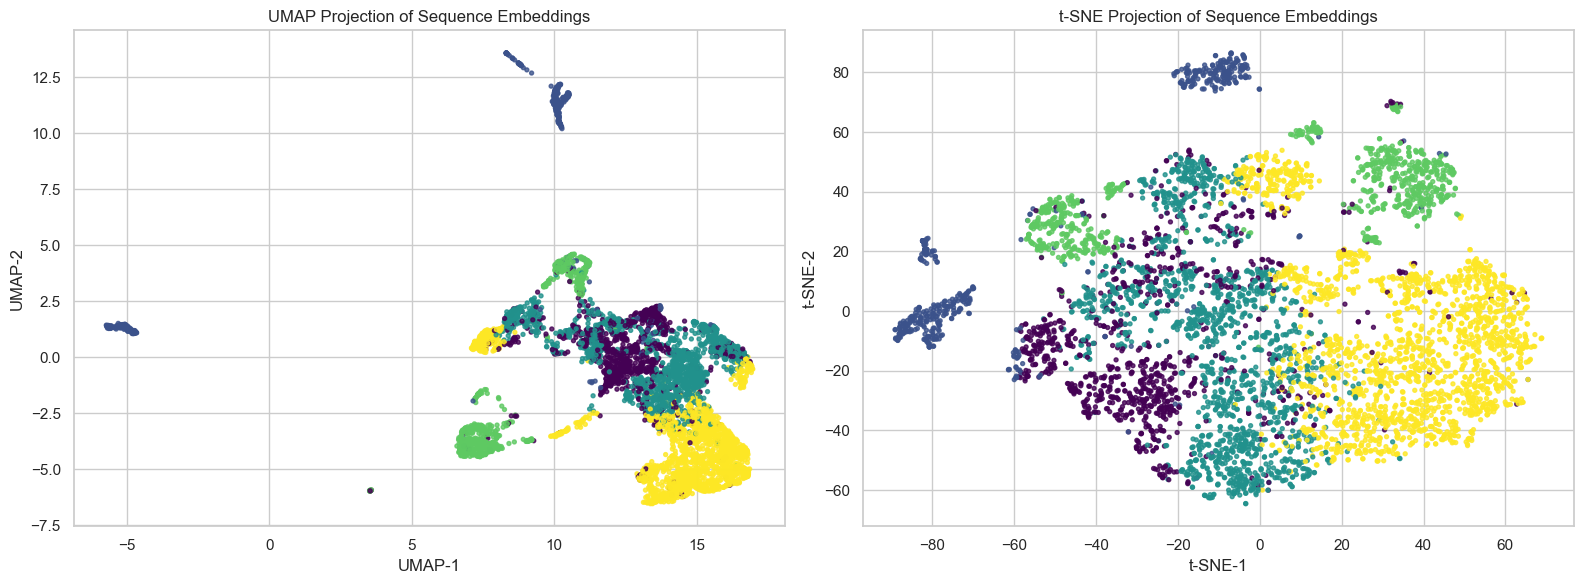

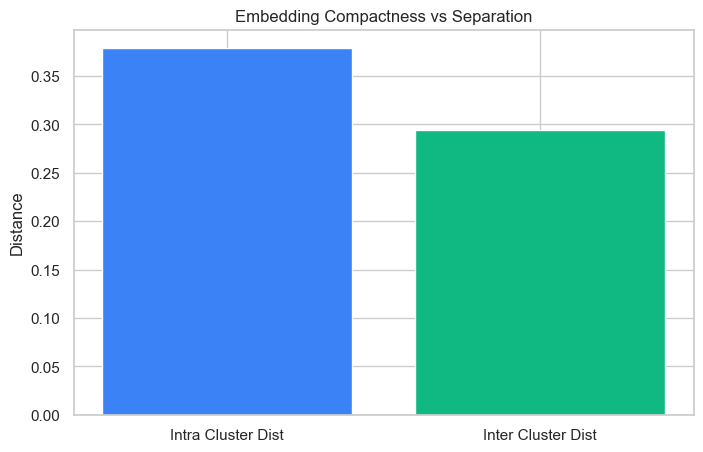

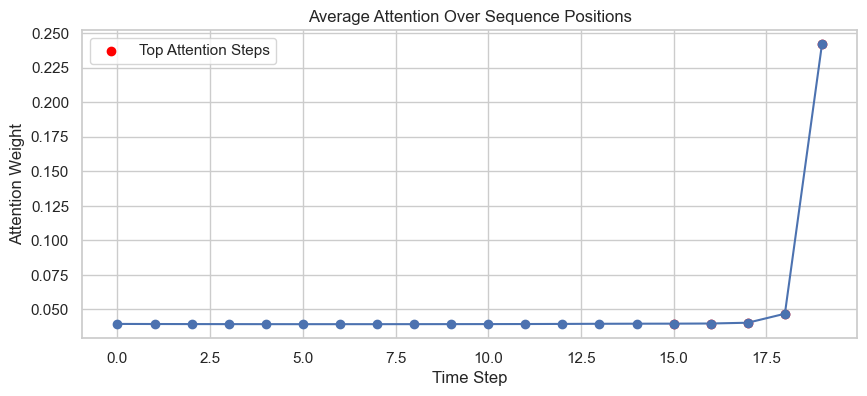

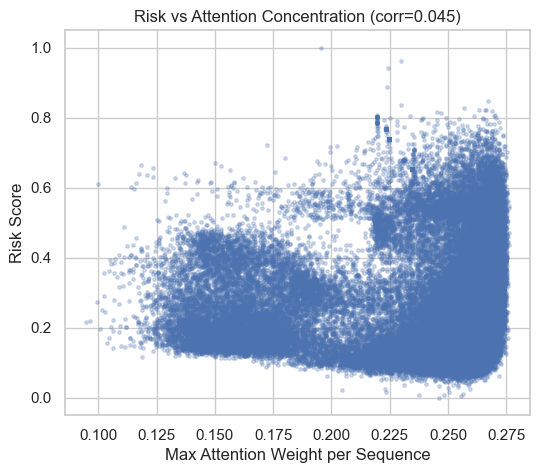

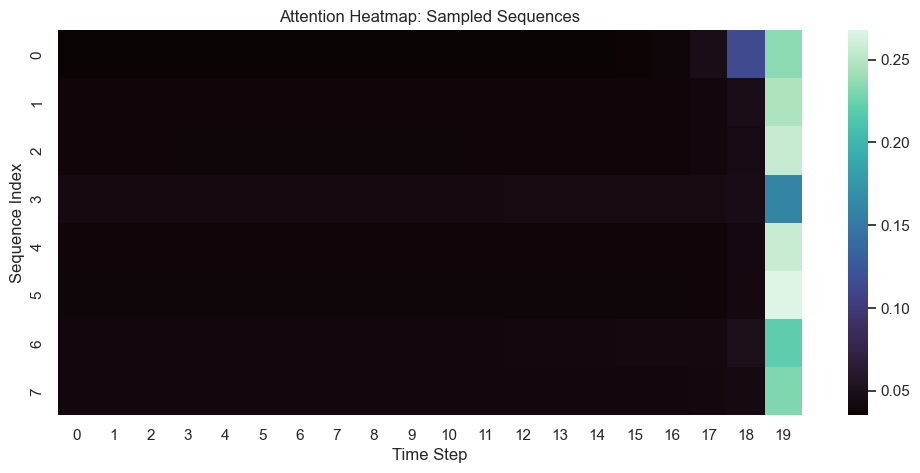

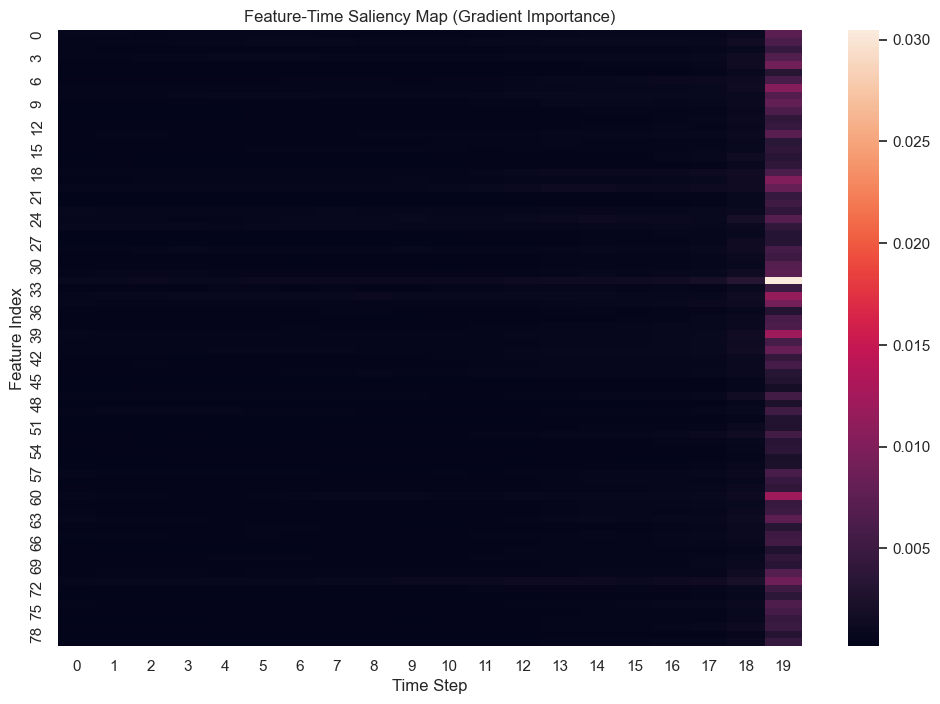

Top attended timesteps: [19, 18, 17, 16, 15]
Risk-attention correlation: 0.04475243899588401


In [10]:
# Cell 16: Advanced interpretability and embedding diagnostics visualizations

sns.set_theme(style="whitegrid")

# 1) UMAP vs t-SNE comparison for embedding geometry
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(
    clustering_outputs["umap_2d"][:, 0],
    clustering_outputs["umap_2d"][:, 1],
    c=clustering_outputs["proj_labels"],
    s=8,
    cmap="viridis",
    alpha=0.8,
)
axes[0].set_title("UMAP Projection of Sequence Embeddings")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

axes[1].scatter(
    clustering_outputs["tsne_2d"][:, 0],
    clustering_outputs["tsne_2d"][:, 1],
    c=clustering_outputs["proj_labels"],
    s=8,
    cmap="viridis",
    alpha=0.8,
)
axes[1].set_title("t-SNE Projection of Sequence Embeddings")
axes[1].set_xlabel("t-SNE-1")
axes[1].set_ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

# 2) Compactness vs separation
em = clustering_outputs["embedding_metrics"].iloc[0]
plt.figure(figsize=(8, 5))
plt.bar(["Intra Cluster Dist", "Inter Cluster Dist"], [em["intra_cluster_distance"], em["inter_cluster_distance"]], color=["#3b82f6", "#10b981"])
plt.title("Embedding Compactness vs Separation")
plt.ylabel("Distance")
plt.show()

# 3) Attention interpretability: top attended time steps
attn_weights_all = attn_all.squeeze(-1)
mean_attention = attn_weights_all.mean(axis=0)
top_steps = np.argsort(mean_attention)[-5:][::-1]

plt.figure(figsize=(10, 4))
plt.plot(np.arange(SEQUENCE_LENGTH), mean_attention, marker="o")
plt.scatter(top_steps, mean_attention[top_steps], color="red", label="Top Attention Steps")
plt.title("Average Attention Over Sequence Positions")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.legend()
plt.show()

# 4) Risk vs attention concentration correlation
attn_concentration = np.max(attn_weights_all, axis=1)
risk_attn_corr = np.corrcoef(output_df["risk_score"].values, attn_concentration)[0, 1]

plt.figure(figsize=(6, 5))
plt.scatter(attn_concentration, output_df["risk_score"].values, s=6, alpha=0.25)
plt.title(f"Risk vs Attention Concentration (corr={risk_attn_corr:.3f})")
plt.xlabel("Max Attention Weight per Sequence")
plt.ylabel("Risk Score")
plt.show()

# 5) Top attention segments examples
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(attn_weights_all), size=min(8, len(attn_weights_all)), replace=False)
plt.figure(figsize=(12, 5))
sns.heatmap(attn_weights_all[sample_idx], cmap="mako", cbar=True)
plt.title("Attention Heatmap: Sampled Sequences")
plt.xlabel("Time Step")
plt.ylabel("Sequence Index")
plt.show()

# 6) Gradient-based feature importance (saliency)
probe_n = min(1024, len(X_feat_scaled))
probe_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_feat_scaled), size=probe_n, replace=False)

x_probe_feat = tf.convert_to_tensor(X_feat_scaled[probe_idx])
x_probe_ctx = tf.convert_to_tensor(X_ctx[probe_idx])
x_probe_sig = tf.convert_to_tensor(X_sig_scaled[probe_idx])

with tf.GradientTape() as tape:
    tape.watch(x_probe_feat)
    outputs = best_model([x_probe_feat, x_probe_ctx, x_probe_sig], training=False)
    next_ctx_prob = outputs[1]
    # Focus gradients on model's own confident predictions (data-driven class selection)
    pred_class = tf.cast(tf.argmax(next_ctx_prob, axis=1), tf.int32)
    batch_idx = tf.range(tf.shape(pred_class)[0], dtype=tf.int32)
    gather_idx = tf.stack([batch_idx, pred_class], axis=1)
    score = tf.gather_nd(next_ctx_prob, gather_idx)

saliency = tf.abs(tape.gradient(score, x_probe_feat)).numpy()
saliency_map = saliency.mean(axis=0).T  # feature x timestep

plt.figure(figsize=(12, 8))
sns.heatmap(saliency_map, cmap="rocket", cbar=True)
plt.title("Feature-Time Saliency Map (Gradient Importance)")
plt.xlabel("Time Step")
plt.ylabel("Feature Index")
plt.show()

print("Top attended timesteps:", top_steps.tolist())
print("Risk-attention correlation:", float(risk_attn_corr))

## Step 8 - Validation and MLOps Summary

In [11]:
# Cell 18: Validation, metrics export, and elite completion summary

# --------------------------
# Strict validation checks
# --------------------------
required_symbols = ["encoder_model", "attention_model", "emb_train", "emb_test", "emb_all", "recon_error_seq", "prediction_error_seq", "attn_all", "likelihood_norm"]
missing_symbols = [name for name in required_symbols if name not in globals()]
assert not missing_symbols, f"Missing required symbols: {missing_symbols}"
assert output_df.isna().sum().sum() == 0, "NaNs found in final output."
assert np.isfinite(emb_all).all(), "Non-finite values found in embeddings."
assert float(np.var(emb_all)) > 0.0, "Embedding variance must be greater than zero."
assert emb_train.shape[0] == int(train_mask.sum()), "Train embedding count mismatch."
assert emb_test.shape[0] == int(test_mask.sum()), "Test embedding count mismatch."
assert emb_all.shape[0] == len(output_df), "All embedding count mismatch."
assert attn_all.shape[0] == len(output_df), "Attention batch count mismatch."
assert attn_all.shape[1] == SEQUENCE_LENGTH, "Attention time dimension mismatch."
assert recon_error_seq.shape[0] == len(output_df), "Reconstruction error length mismatch."
assert prediction_error_seq.shape[0] == len(output_df), "Prediction error length mismatch."
assert np.isfinite(likelihood_norm).all(), "Likelihood norm has non-finite values."
assert np.isfinite(output_df.select_dtypes(include=[np.number]).values).all(), "Output numeric fields contain Inf/NaN."
assert float(np.mean(np.var(emb_all, axis=0))) > 1e-5, "Embedding variance threshold failed (possible collapse)."
cluster_counts = output_df["behavior_cluster"].value_counts(normalize=True)
assert float(cluster_counts.max()) < 0.95, "Cluster distribution collapsed: one cluster dominates >95%."
assert float(np.std(contrastive_margin)) > 1e-4, "Contrastive margin distribution collapsed."
assert float(np.mean(contrastive_margin)) > 0.30, "Contrastive margin mean is too low for robust separation."
assert float(output_df["risk_score"].between(0.0, 1.0).mean()) == 1.0, "Risk score must be bounded in [0,1]."
risk_iqr = float(output_df["risk_score"].quantile(0.75) - output_df["risk_score"].quantile(0.25))
assert risk_iqr > 0.03, "Risk score IQR too small (distribution collapse)."

for col in [
    "risk_score",
    "behavior_score",
    "anomaly_score",
    "final_anomaly_score",
    "uncertainty_score",
    "normalized_sequence_likelihood",
    "sequence_temporal_anomaly",
    "temporal_score",
]:
    mn, mx = float(output_df[col].min()), float(output_df[col].max())
    assert mn >= -1e-8 and mx <= 1.0 + 1e-8, f"{col} is outside [0,1]: ({mn}, {mx})"

assert output_df["trip_id"].nunique() >= 2, "Need at least 2 trips in output."
assert output_df["behavior_cluster"].nunique() >= 2, "Need at least 2 behavior clusters."
assert output_df["behavior_phase_id"].nunique() >= 1, "Behavior phases were not created."
assert output_df["number_of_phases_per_trip"].min() >= 1, "Phase count must be at least 1."
assert output_df["phase_transition_frequency"].between(0.0, 1.0).all(), "Phase transition frequency out of bounds."
assert output_df["normalized_sequence_likelihood"].between(0.0, 1.0).all(), "Normalized sequence likelihood out of bounds."
assert set(meta_train["trip_id"]).isdisjoint(set(meta_test["trip_id"])), "Trip-wise split leakage detected."
assert float(output_df["risk_score"].std()) > 0.01, "Risk distribution is collapsed."
assert float(output_df["final_anomaly_score"].std()) > 0.01, "Anomaly distribution is collapsed."
assert float(output_df["risk_score"].quantile(0.95) - output_df["risk_score"].quantile(0.05)) > 0.05, "Risk score spread is too small."
assert float(output_df["final_anomaly_score"].quantile(0.95) - output_df["final_anomaly_score"].quantile(0.05)) > 0.05, "Anomaly score spread is too small."

# --------------------------
# Generalization quality checks (cross-trip)
# --------------------------
train_risk = output_df.loc[train_mask, "risk_score"].values
test_risk = output_df.loc[test_mask, "risk_score"].values
risk_shift = float(abs(np.mean(train_risk) - np.mean(test_risk)))

train_emb_norm = np.linalg.norm(emb_train, axis=1)
test_emb_norm = np.linalg.norm(emb_test, axis=1)
embedding_consistency_gap = float(abs(np.mean(train_emb_norm) - np.mean(test_emb_norm)))

train_anom = output_df.loc[train_mask, "final_anomaly_score"].values
test_anom = output_df.loc[test_mask, "final_anomaly_score"].values
anomaly_shift = float(abs(np.mean(train_anom) - np.mean(test_anom)))

# --------------------------
# Metrics export
# --------------------------
runtime_seconds = float(time.time() - start_time)
metrics = {
    "input_rows": int(len(df)),
    "num_sequences": int(len(output_df)),
    "num_trips": int(df["trip_id"].nunique()),
    "train_trips": int(len(train_trips)),
    "test_trips": int(len(test_trips)),
    "sequence_length": int(SEQUENCE_LENGTH),
    "num_features": int(len(feature_cols)),
    "embedding_dim": int(emb_all.shape[1]),
    "best_sequence_architecture": best_arch,
    "best_val_loss": float(best_val_eval["loss"]),
    "best_val_eval": {k: float(v) for k, v in best_val_eval.items()},
    "sequence_cluster_model": str(clustering_outputs["embedding_metrics"].iloc[0]["best_sequence_cluster_model"]),
    "sequence_cluster_param": str(clustering_outputs["embedding_metrics"].iloc[0]["best_sequence_cluster_param"]),
    "silhouette": float(clustering_outputs["embedding_metrics"].iloc[0]["sequence_silhouette"]),
    "davies_bouldin": float(clustering_outputs["embedding_metrics"].iloc[0]["sequence_db_index"]),
    "calinski_harabasz": float(clustering_outputs["embedding_metrics"].iloc[0]["sequence_ch_score"]),
    "intra_cluster_distance": float(clustering_outputs["embedding_metrics"].iloc[0]["intra_cluster_distance"]),
    "inter_cluster_distance": float(clustering_outputs["embedding_metrics"].iloc[0]["inter_cluster_distance"]),
    "distance_ratio_inter_over_intra": float(clustering_outputs["embedding_metrics"].iloc[0]["distance_ratio_inter_over_intra"]),
    "ari_stability": float(clustering_outputs["stability_ari"]),
    "avg_behavior_score": float(output_df["behavior_score"].mean()),
    "avg_risk_score": float(output_df["risk_score"].mean()),
    "avg_anomaly_score": float(output_df["anomaly_score"].mean()),
    "avg_sequence_likelihood": float(output_df["normalized_sequence_likelihood"].mean()),
    "risk_std": float(output_df["risk_score"].std()),
    "risk_q05": float(output_df["risk_score"].quantile(0.05)),
    "risk_q50": float(output_df["risk_score"].quantile(0.50)),
    "risk_q95": float(output_df["risk_score"].quantile(0.95)),
    "generalization_risk_shift": risk_shift,
    "generalization_embedding_gap": embedding_consistency_gap,
    "generalization_anomaly_shift": anomaly_shift,
    "runtime_seconds": runtime_seconds,
    "risk_target_source": str(risk_target_source),
    "best_contrastive_temperature": float(best_temp),
}

with open(MODEL_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

joblib.dump(
    {
        "embedding_dim": int(emb_all.shape[1]),
        "feature_columns": feature_cols,
        "sequence_length": SEQUENCE_LENGTH,
        "best_architecture": best_arch,
    },
    MODEL_DIR / "embedding_model.joblib",
)

print("All validation checks passed.")
print("Saved:")
print("  -", OUTPUT_CSV)
print("  -", DRIVER_PROFILE_CSV)
print("  -", EMBEDDING_METRICS_CSV)
print("  -", FEATURE_IMPORTANCE_CSV)
print("  -", MODEL_DIR / "sequence_model.keras")
print("  -", MODEL_DIR / "embedding_model.keras")
print("  -", MODEL_DIR / "clustering_model.joblib")
print("  -", MODEL_DIR / "risk_model_nn.keras")
print("  -", MODEL_DIR / "metrics.json")
print("\nRuntime (seconds):", f"{runtime_seconds:.2f}")
print("Best architecture:", best_arch)
print("Silhouette:", f"{metrics['silhouette']:.4f}")
print("ARI stability:", f"{metrics['ari_stability']:.4f}")

All validation checks passed.
Saved:
  - ..\data\features\final_driver_behavior.csv
  - ..\data\features\driver_profile.csv
  - ..\data\features\embedding_metrics.csv
  - ..\data\features\feature_importance.csv
  - ..\models\driver_behavior_v4\sequence_model.keras
  - ..\models\driver_behavior_v4\embedding_model.keras
  - ..\models\driver_behavior_v4\clustering_model.joblib
  - ..\models\driver_behavior_v4\risk_model_nn.keras
  - ..\models\driver_behavior_v4\metrics.json

Runtime (seconds): 7594.97
Best architecture: bilstm_attn
Silhouette: 0.0680
ARI stability: 0.5308
